In [1]:
import seaborn as sns
import matplotlib.pyplot as plt # plotting
from sklearn.model_selection import train_test_split ## without validation set
from sklearn.metrics import f1_score, fbeta_score ## new metric
from collections import Counter
from xgboost import plot_importance, XGBClassifier ## XGBoost out of sklearn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve, cross_validate ## StratifiedKFold preserves the imbalance of the dataset
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore")




In [2]:
#! pip install pandas_profiling

In [ ]:
# from google.colab import files
# files.upload()

Saving fetal_health.csv to fetal_health (1).csv


{'fetal_health (1).csv': b'baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health\n120.0,0.0,0.0,0.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0\n132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0\n133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0\n134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0\n132.0,0.007,0.0,0.008,0.0,0.0,0.0,16.0,2.4,0.0,1

In [2]:
df = pd.read_csv("../../data/fetal_health.csv")
df

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,7.2,40.0,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,7.1,66.0,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,6.1,67.0,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,7.0,66.0,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


In [3]:
df.columns

Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='object')

In [4]:
df.fetal_health.value_counts()

# 1: normal,
# 2: suspect,
#3: pathological

fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64

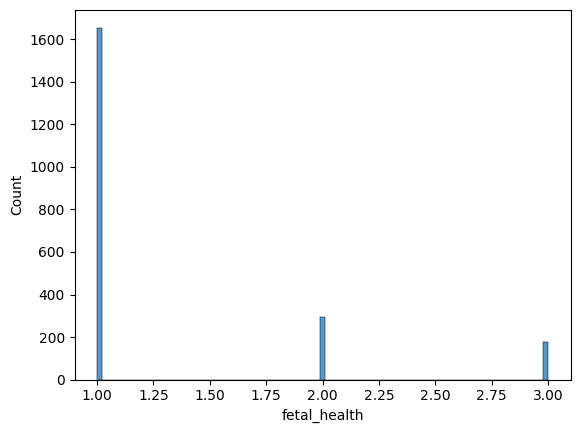

In [5]:
sns.histplot(df.fetal_health)
plt.show()

In [6]:
df.isna().any()

baseline value                                            False
accelerations                                             False
fetal_movement                                            False
uterine_contractions                                      False
light_decelerations                                       False
severe_decelerations                                      False
prolongued_decelerations                                  False
abnormal_short_term_variability                           False
mean_value_of_short_term_variability                      False
percentage_of_time_with_abnormal_long_term_variability    False
mean_value_of_long_term_variability                       False
histogram_width                                           False
histogram_min                                             False
histogram_max                                             False
histogram_number_of_peaks                                 False
histogram_number_of_zeroes              

## Pandas profiling: showing on VS code on Saturday

In [9]:
#! pip install pandas-profiling

In [4]:
from ydata_profiling import ProfileReport

import pandas as pd

df = pd.read_csv("../../data/fetal_health.csv")

profile = ProfileReport(
    df,
    title="Data Profiling Report",
    minimal=True,
    progress_bar=False,
    missing_diagrams={"heatmap": False, "dendrogram": False}  # note: 'dendrogram' spelling fixed
)

profile.to_file("report.html")


100%|██████████| 22/22 [00:00<00:00, 1185.67it/s]


In [3]:
import os
import pandas as pd
from ydata_profiling import ProfileReport ## works with python 3.12 or 3.11 and numpy < 2

df = pd.read_csv("../../data/fetal_health.csv")

profile = ProfileReport(
    df,
    title="Data Profiling Report",
    minimal=True,
    progress_bar=False,
    # spelling must be exactly "dendrogram"
    missing_diagrams={"heatmap": False, "dendrogram": False}
)

out_path = os.path.abspath("report.html")
profile.to_file(out_path, silent=False)
print("Wrote:", out_path, "Exists:", os.path.exists(out_path))

100%|██████████| 22/22 [00:00<00:00, 1277.14it/s]


Wrote: /Users/andredeoliveiragomes/data-science-ML-course-2025/notebooks/week11/report.html Exists: True


In [4]:
import pandas as pd
import sweetviz as sv

import numpy as np
if not hasattr(np, 'VisibleDeprecationWarning'):
    import warnings
    np.VisibleDeprecationWarning = warnings.DeprecationWarning

import sweetviz as sv

# Load your data
df = pd.read_csv("../../data/fetal_health.csv")

# Create the report
report = sv.analyze(df)

# Save to HTML
report.show_html("report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [11]:
features = df.columns
features_explanatory =  ['uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency']

In [12]:
X = pd.DataFrame(df, columns = features_explanatory)
y = df.fetal_health -1
y.value_counts()

fetal_health
0.0    1655
1.0     295
2.0     176
Name: count, dtype: int64

In [13]:
data = df

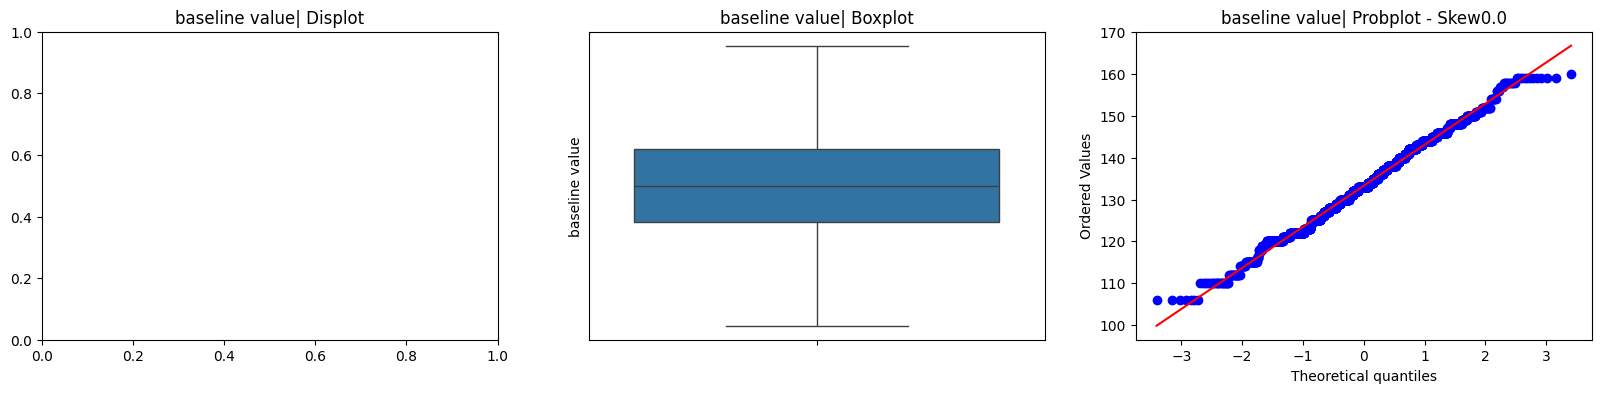

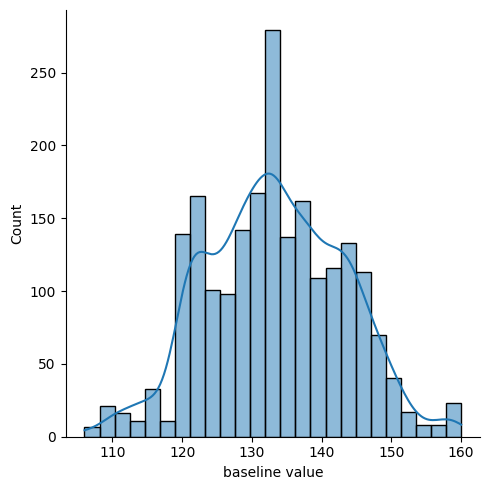

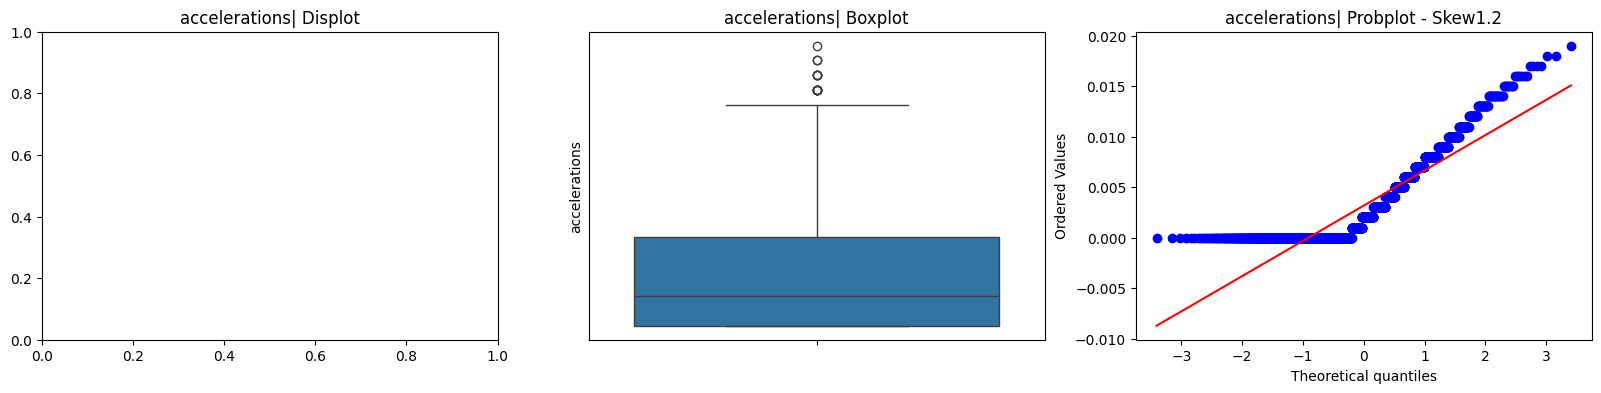

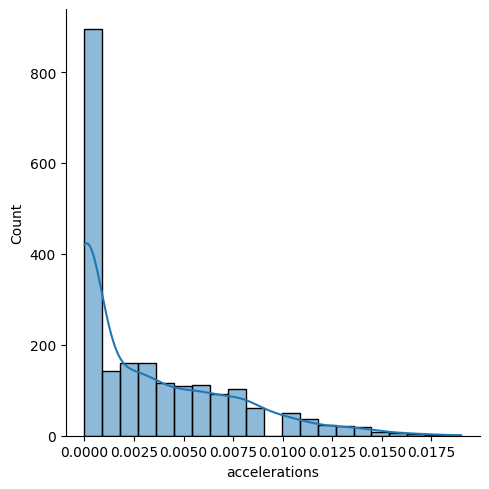

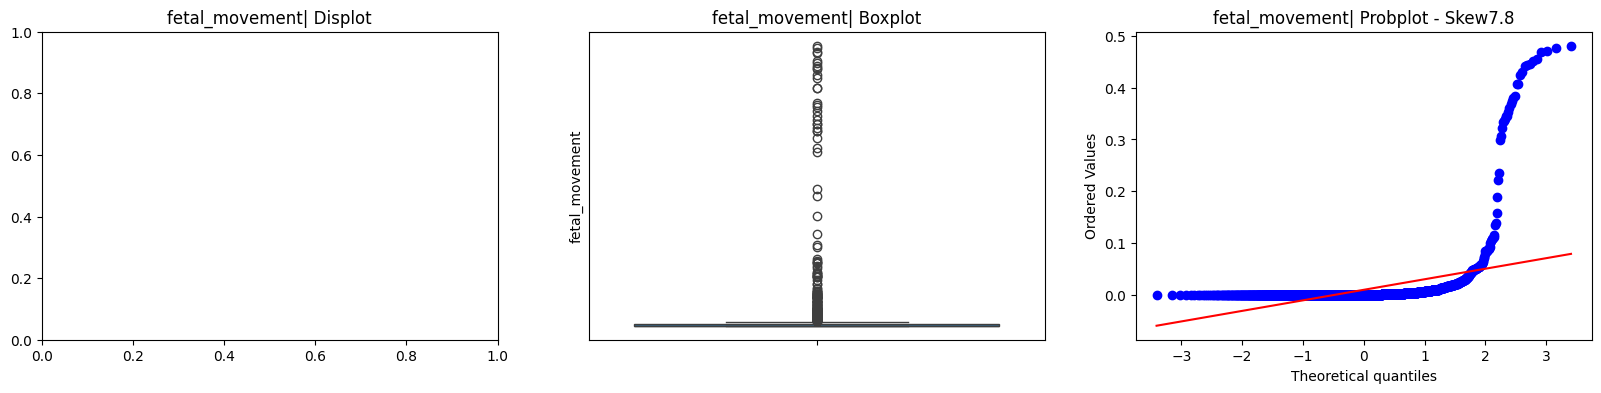

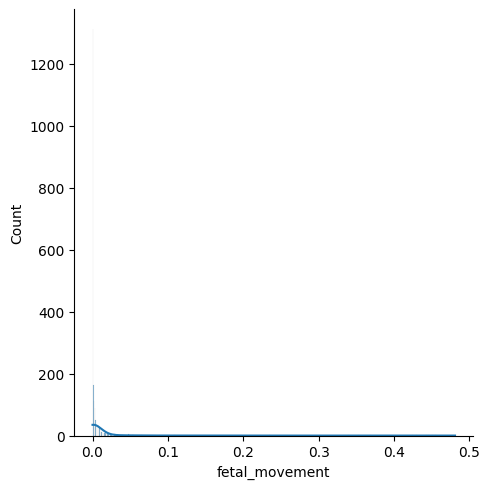

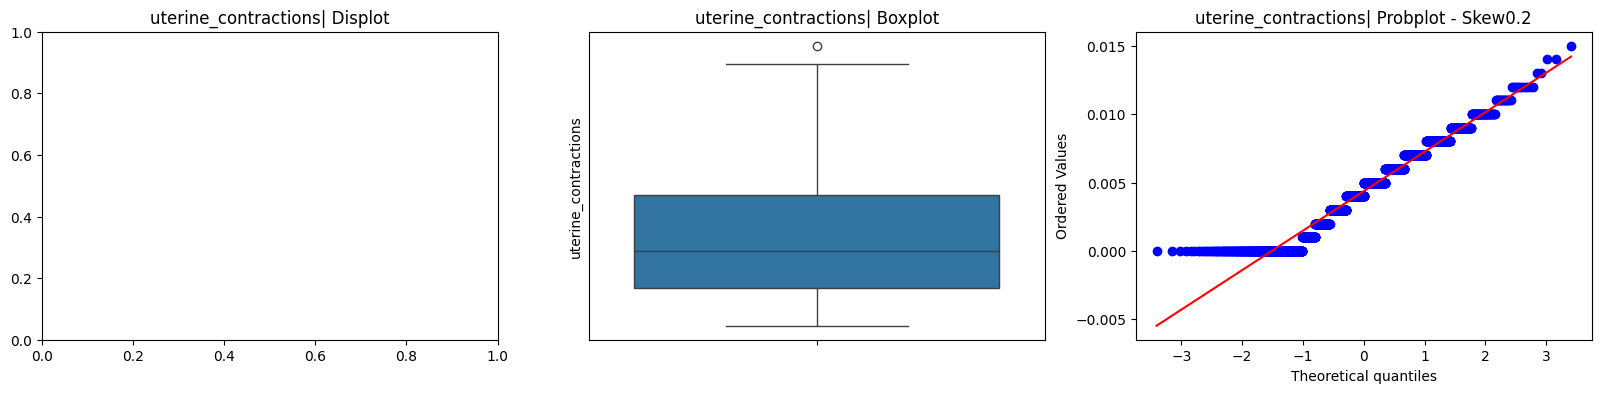

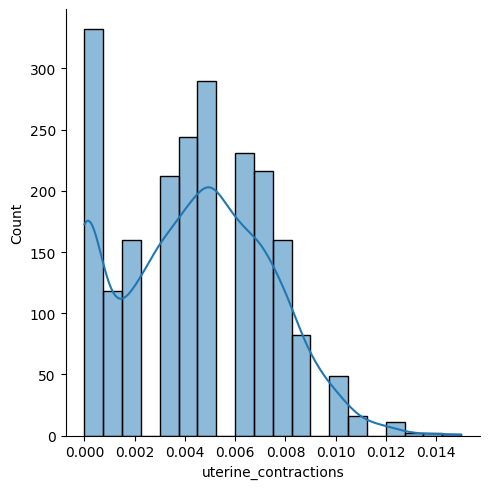

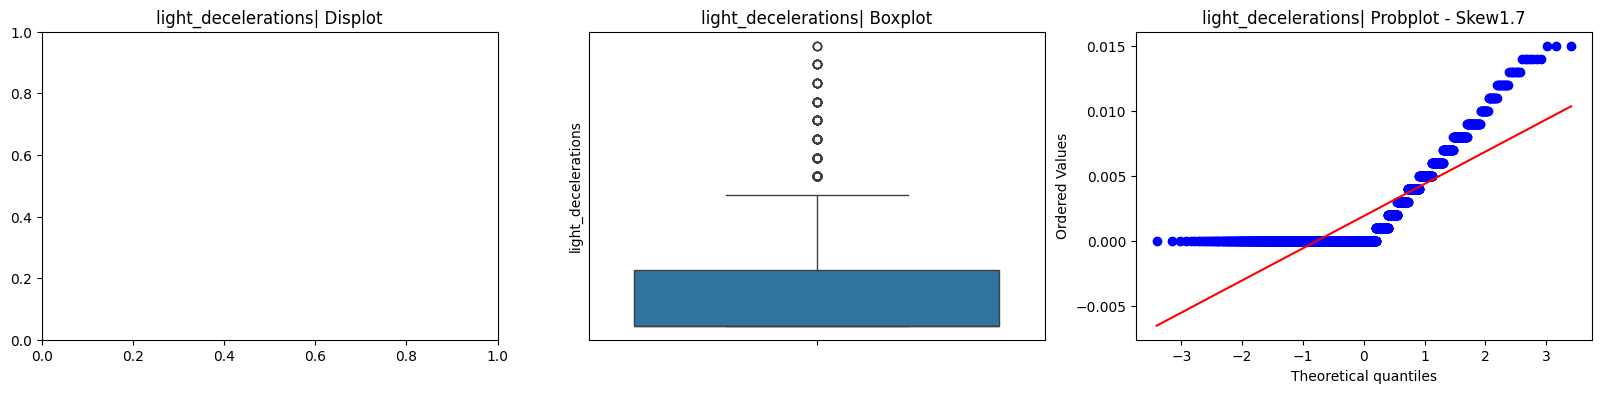

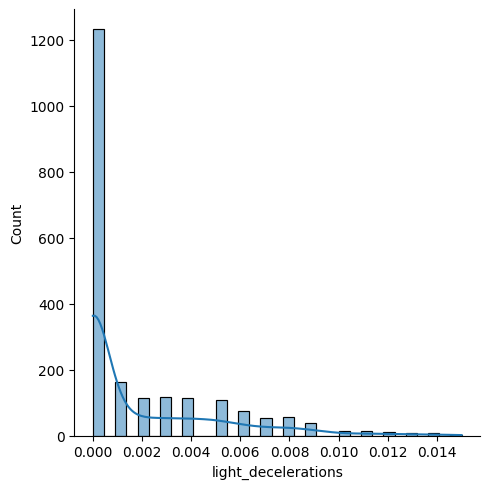

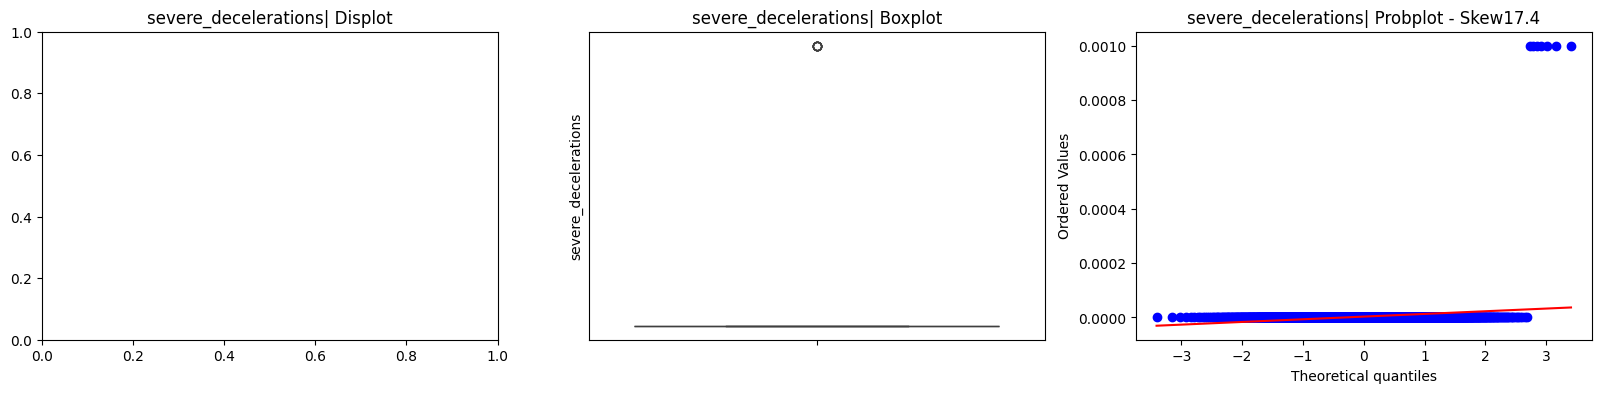

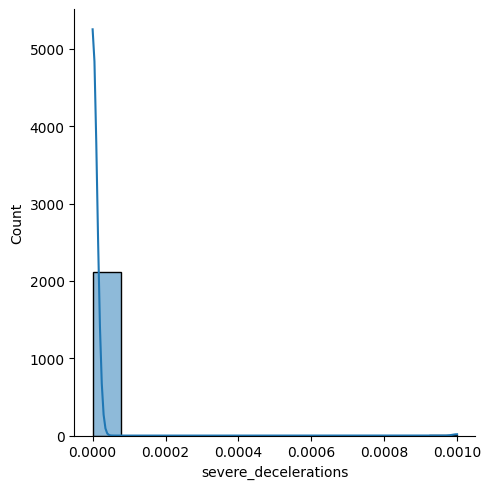

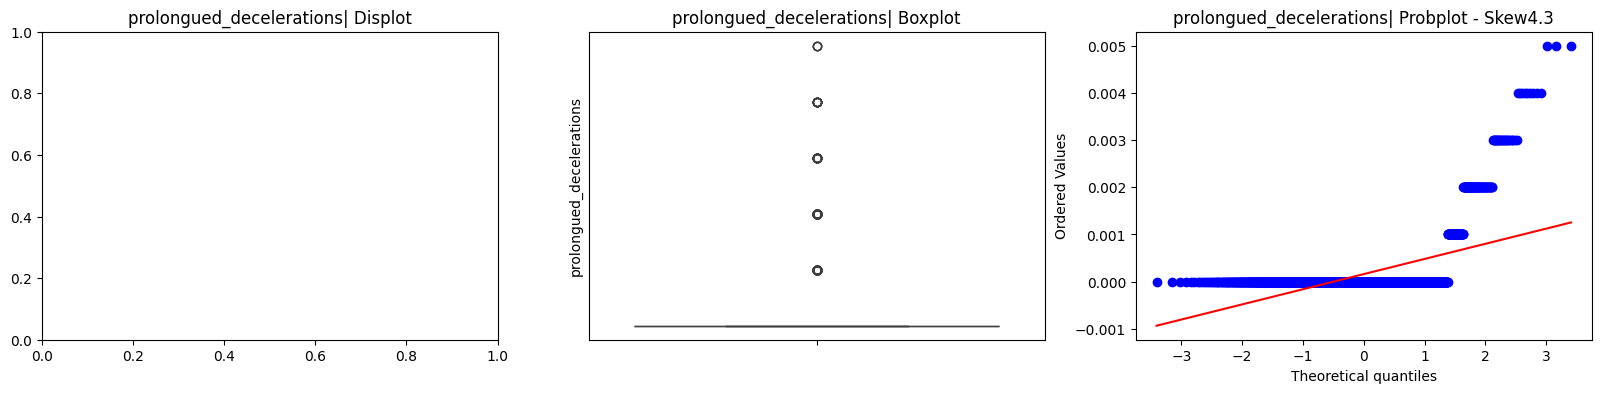

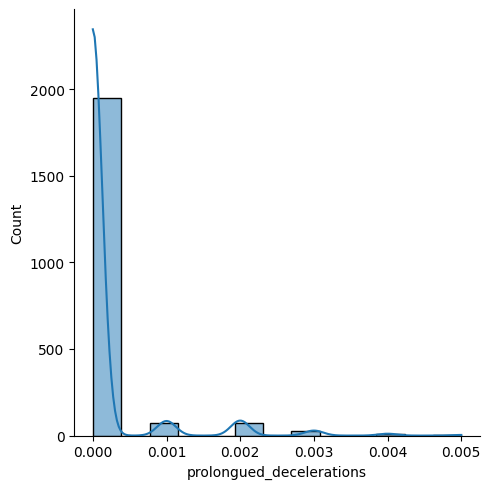

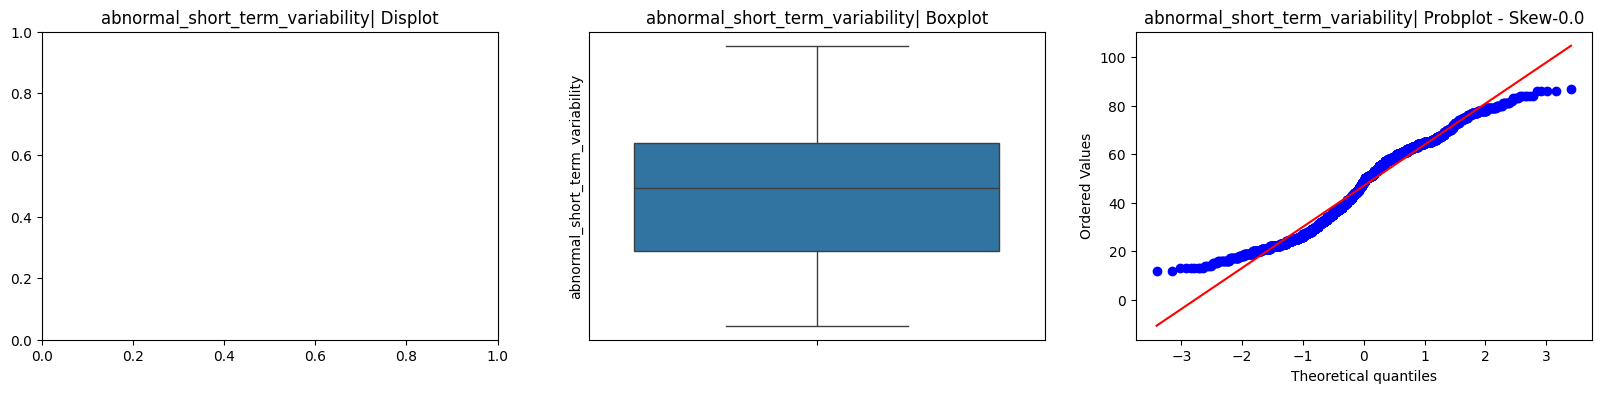

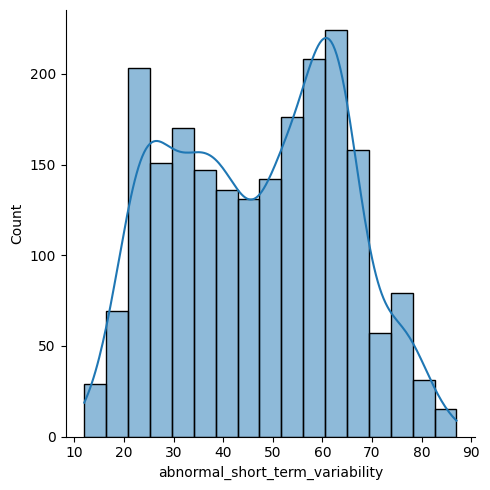

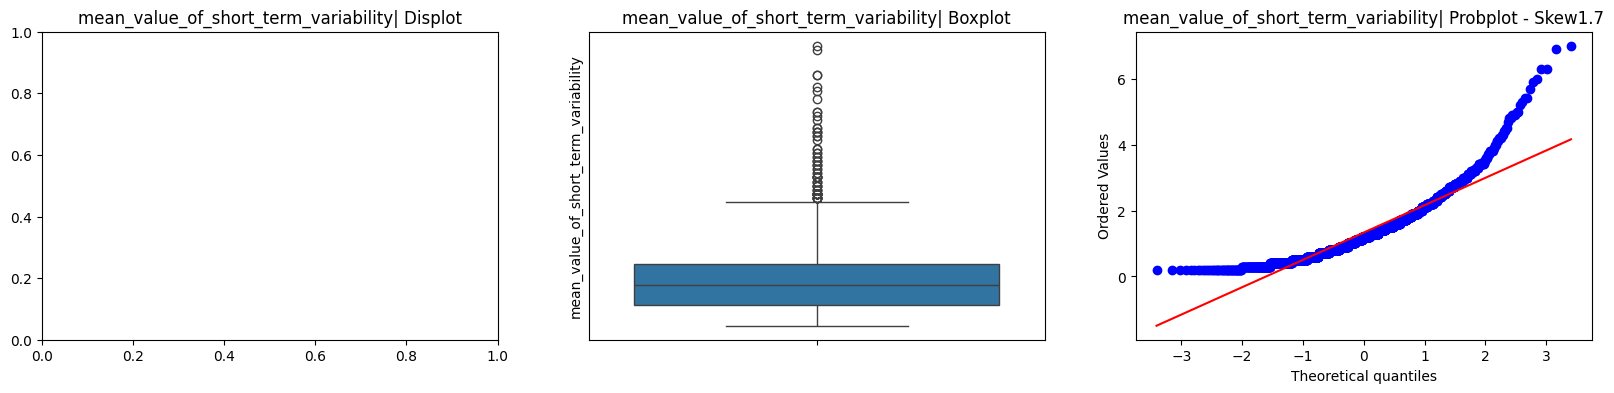

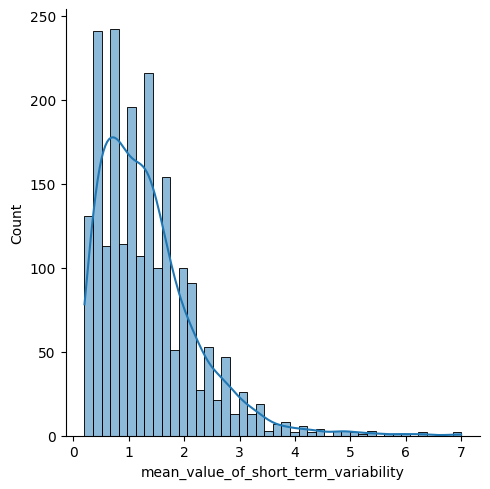

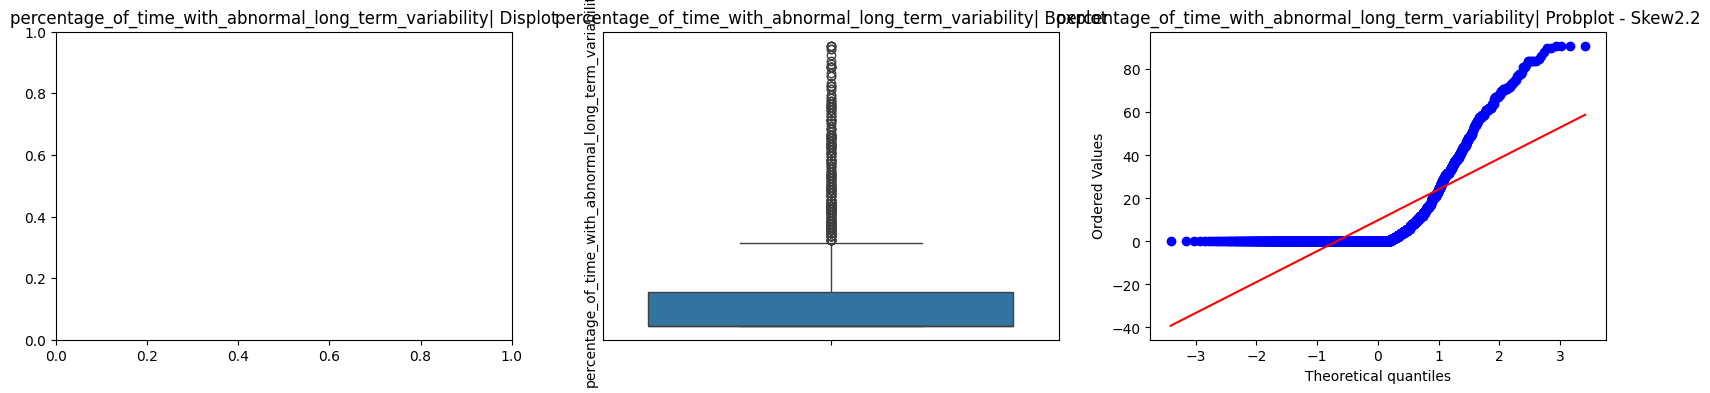

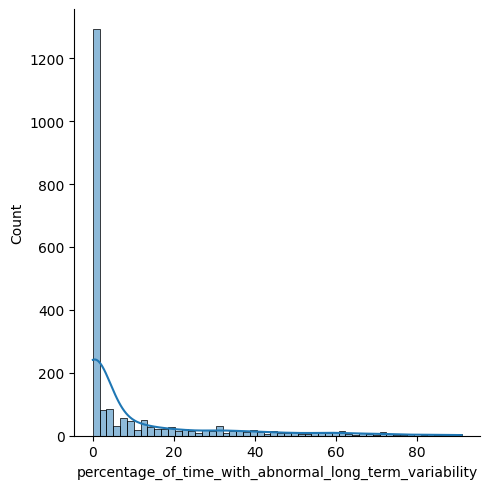

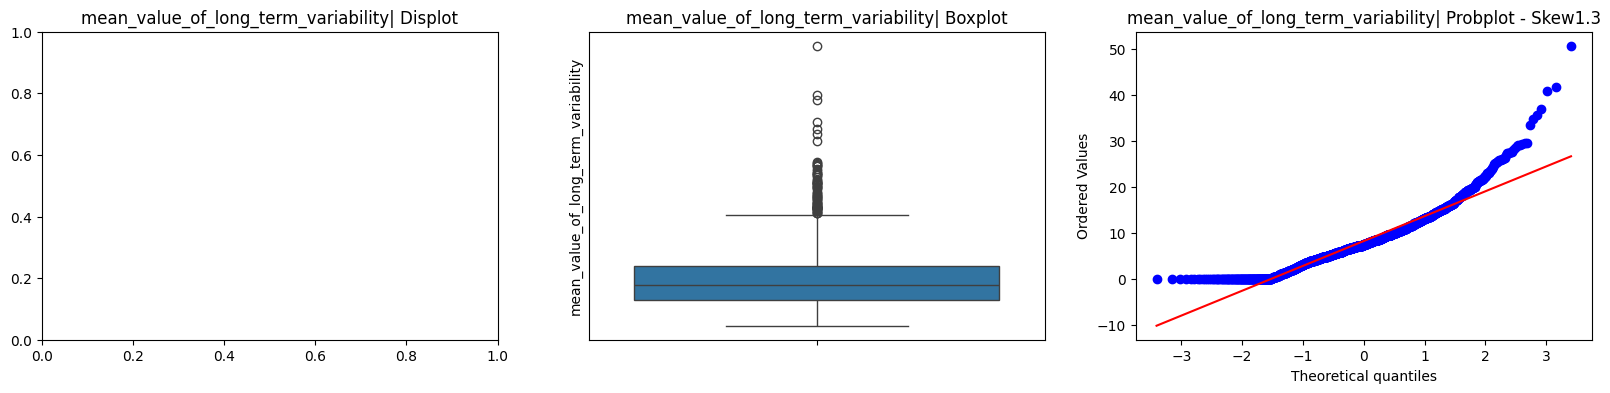

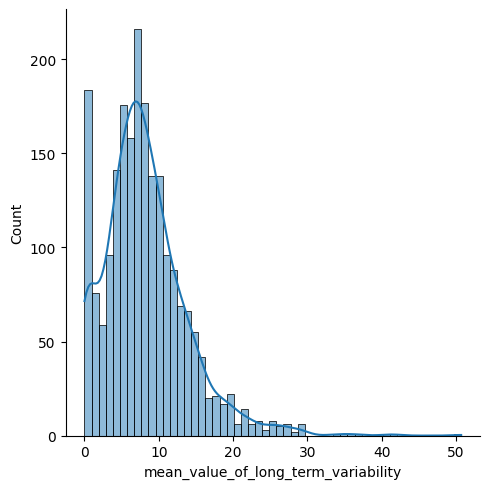

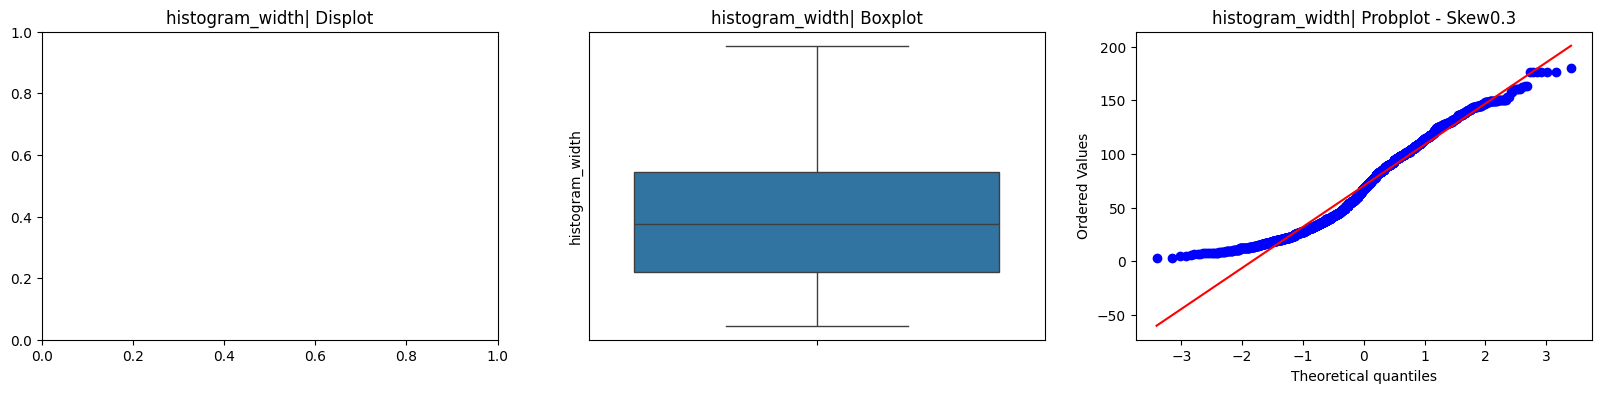

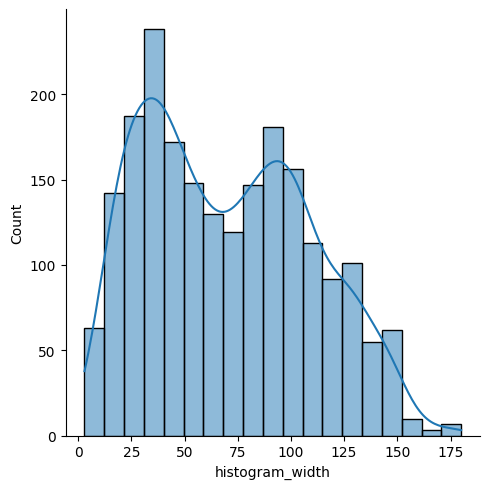

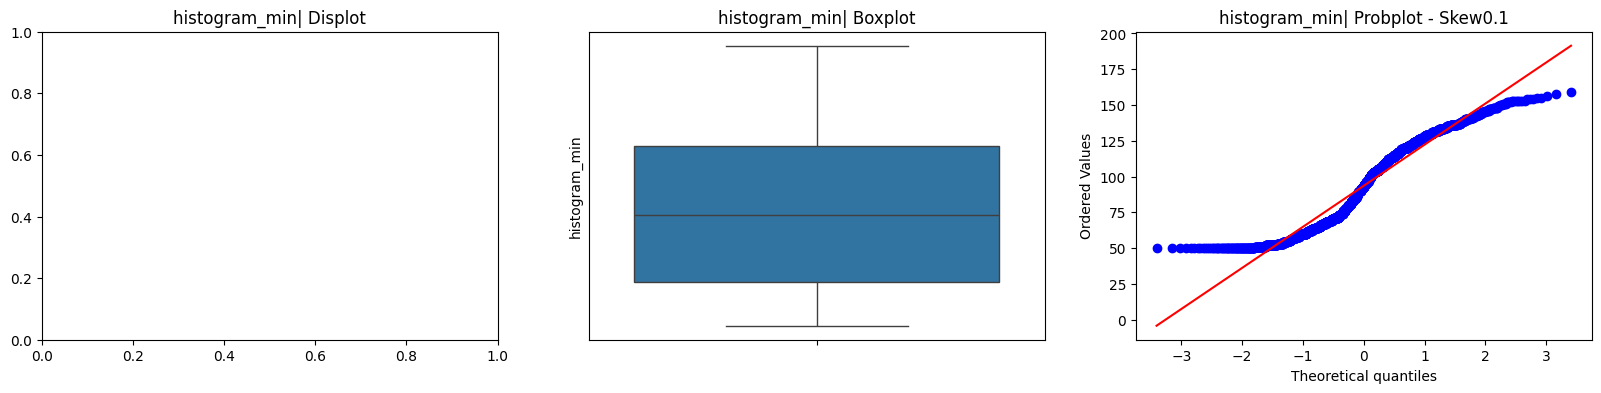

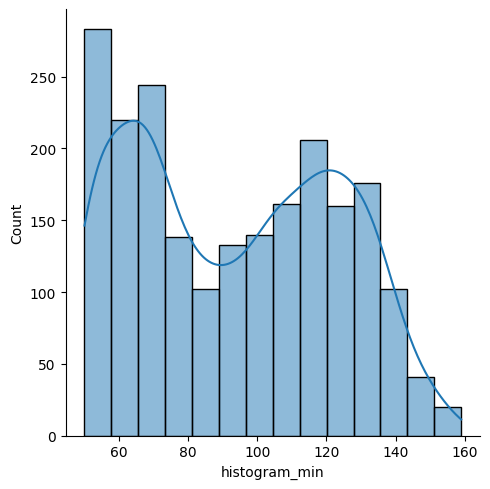

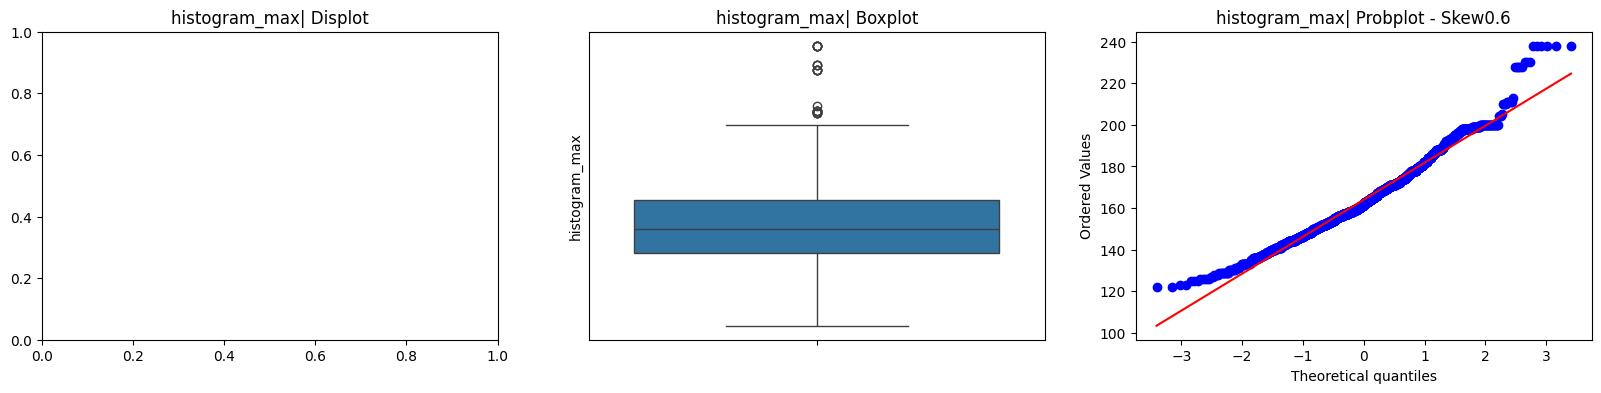

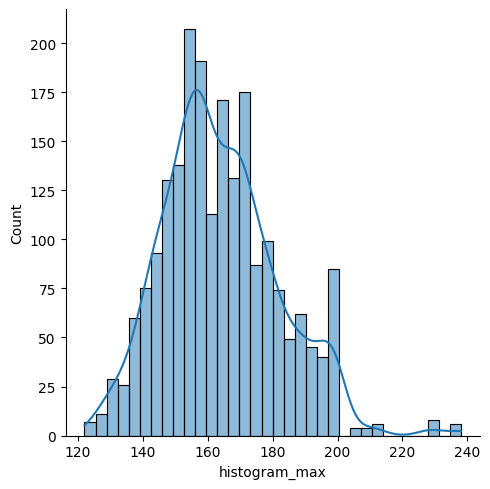

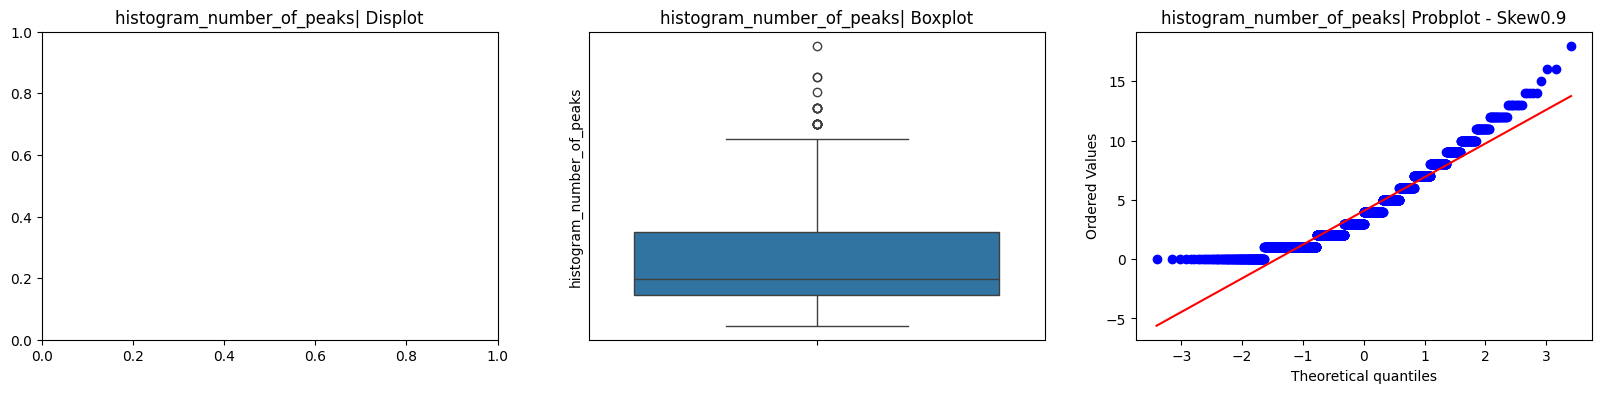

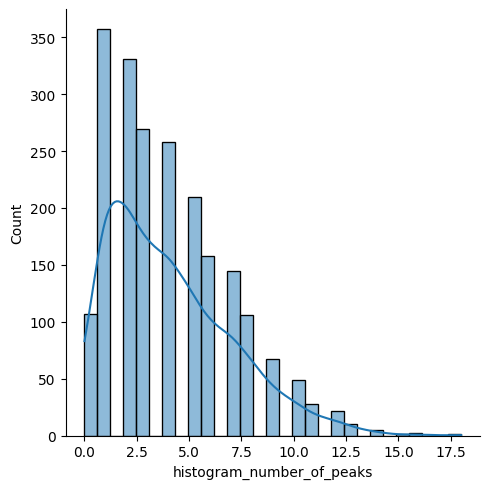

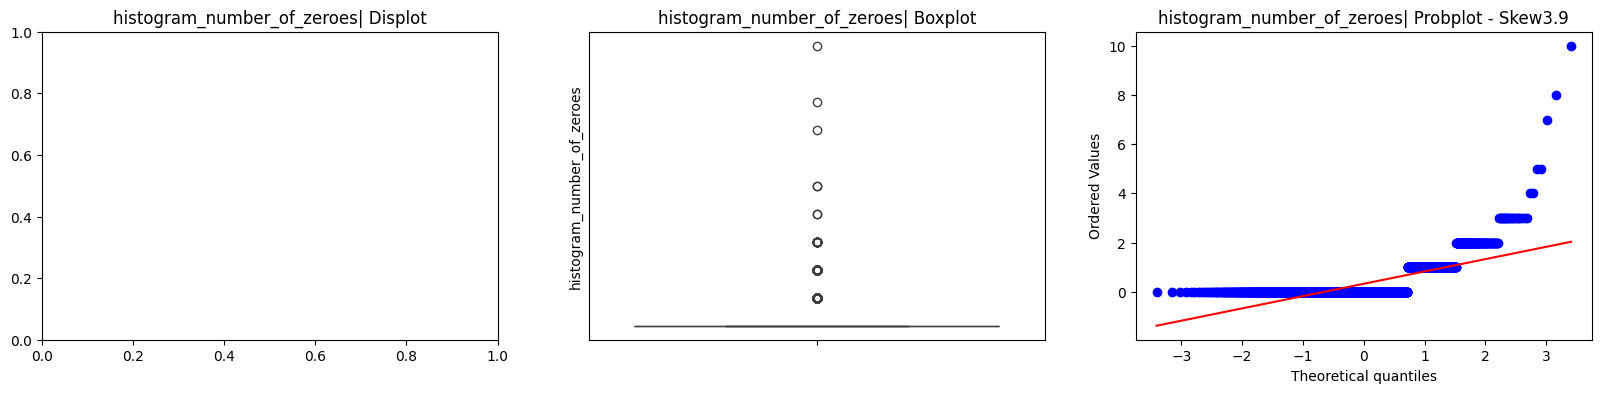

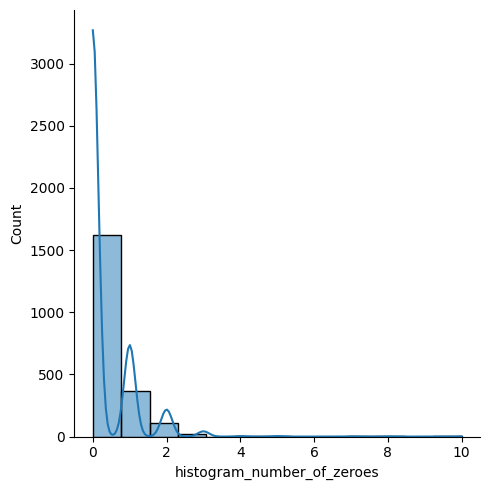

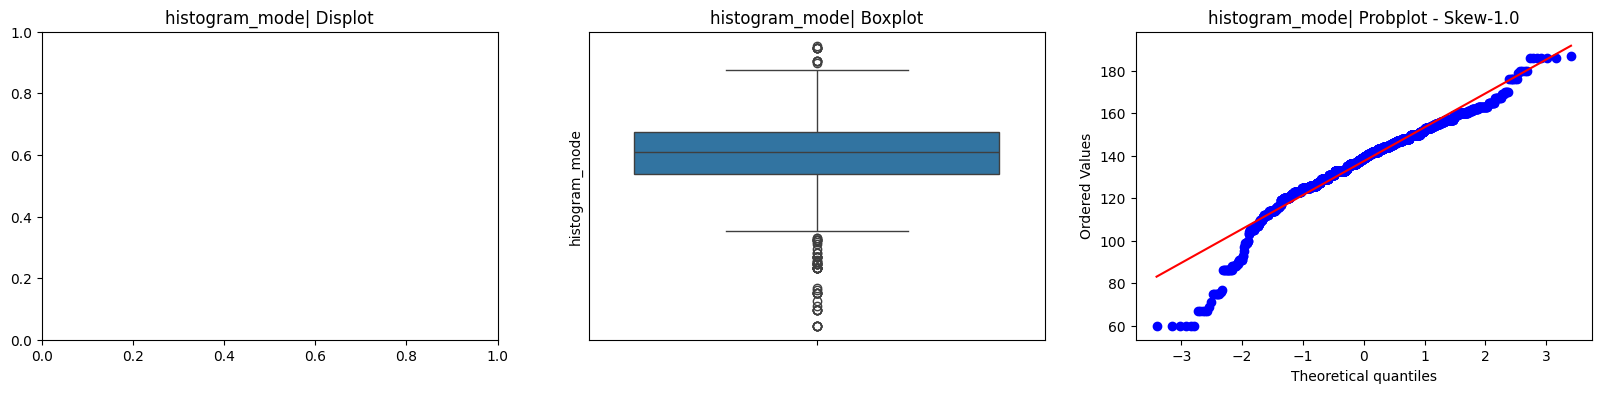

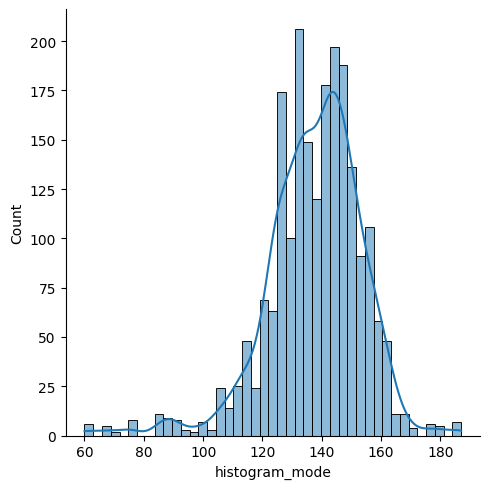

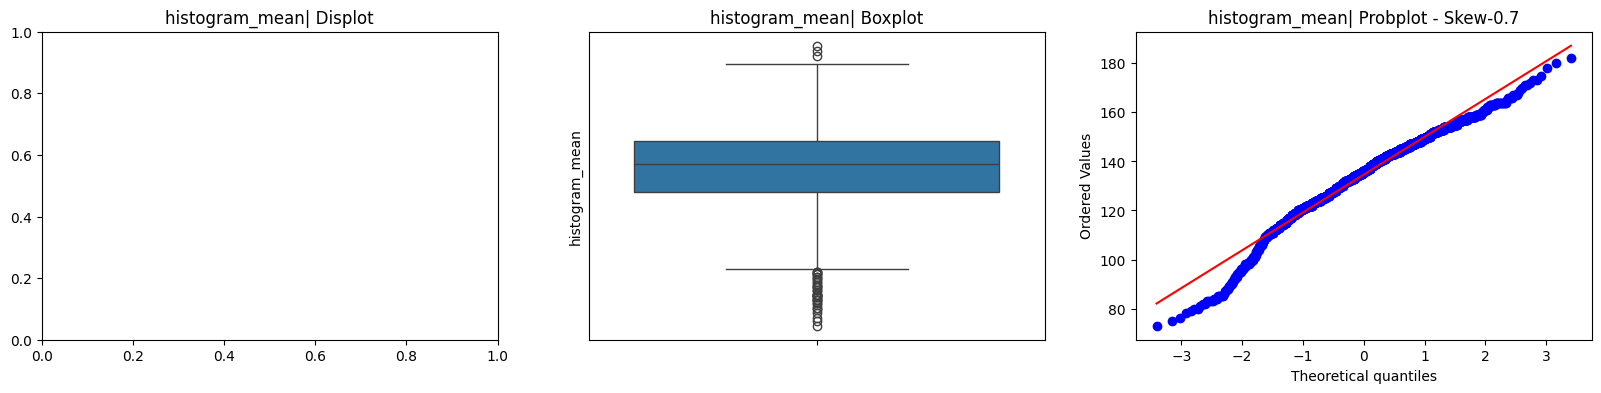

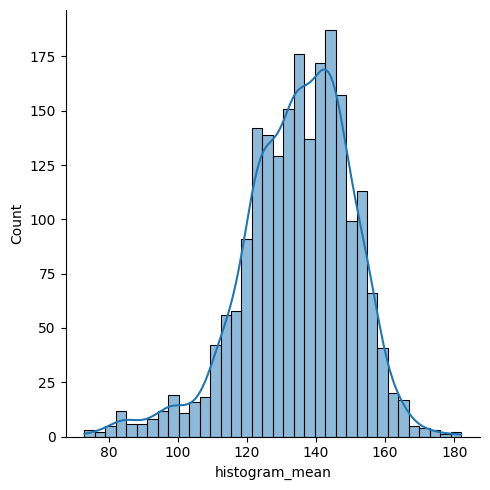

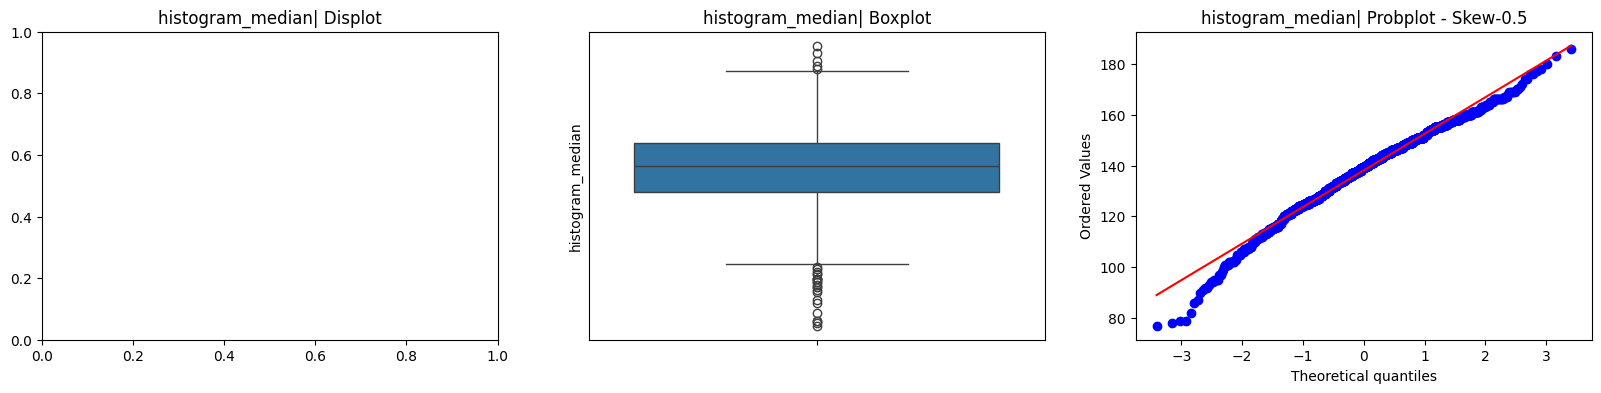

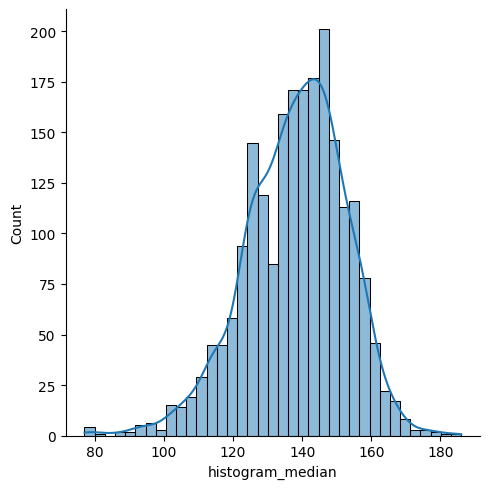

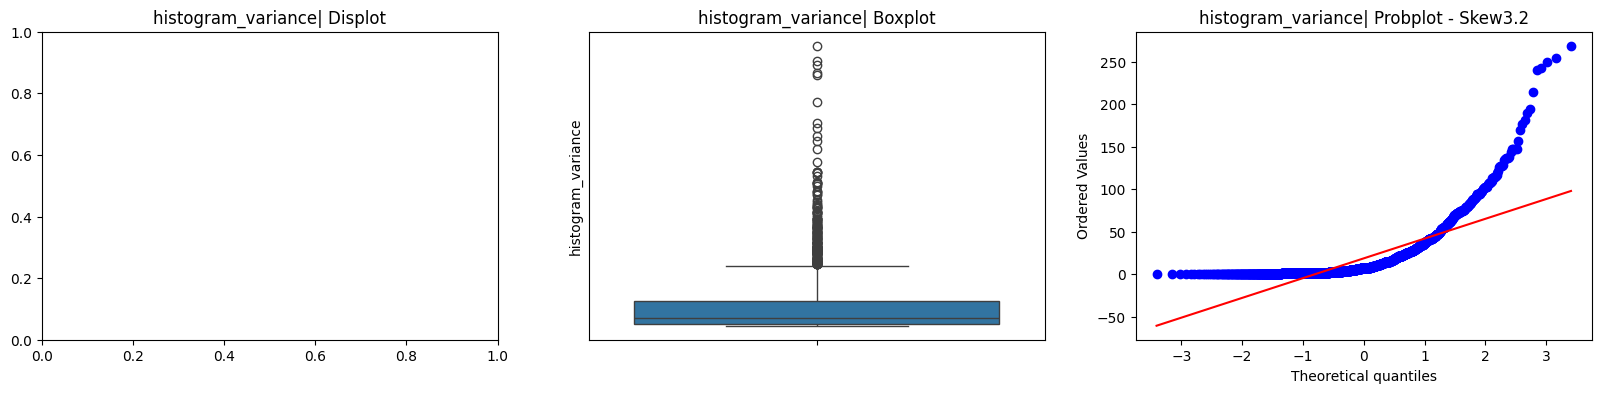

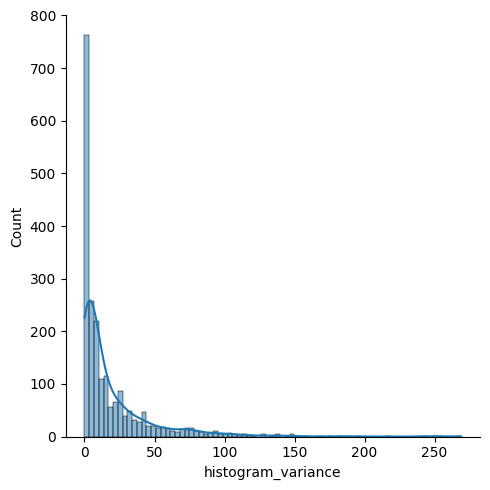

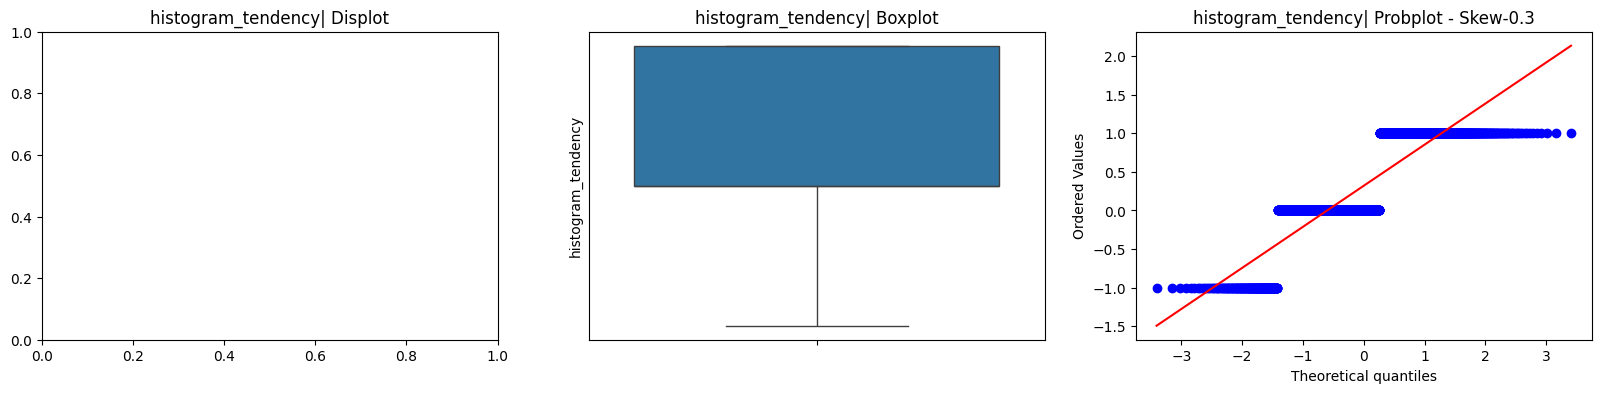

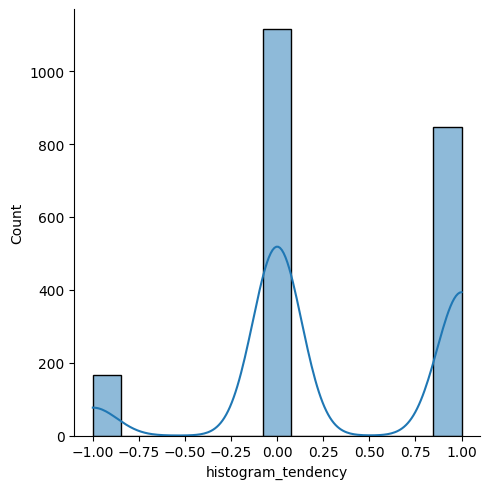

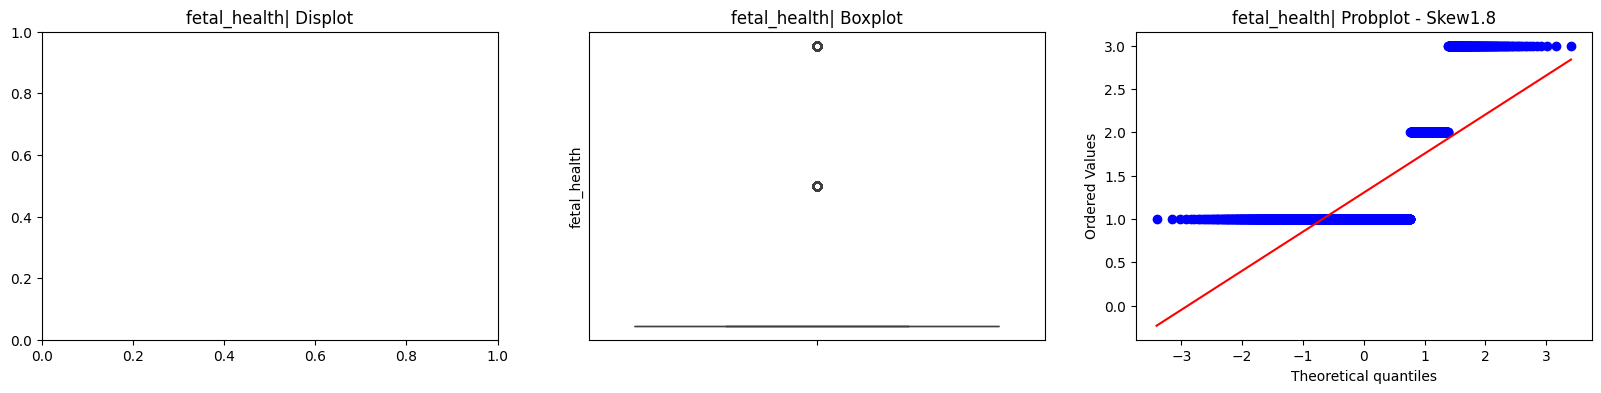

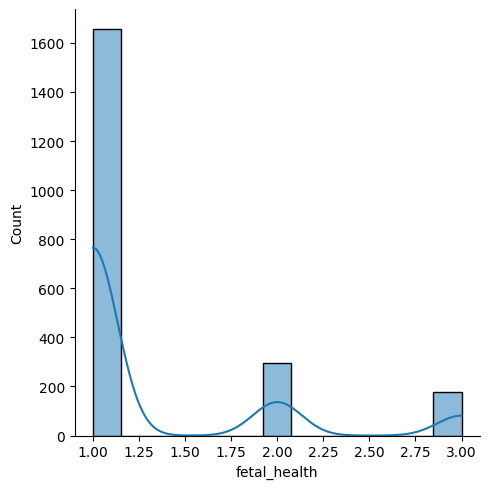

In [14]:
from scipy.stats import probplot, skew

for feature in features:
    fig, axes = plt.subplots(1,3, figsize =(20,4))
    sns.displot(data[feature], kde=True, ax = axes[0])
    sns.boxplot(data[feature], ax= axes[1])
    probplot(data[feature], plot = axes[2])
    skew_val = round(data[feature].skew(),1)
    axes[1].set_yticklabels([])
    axes[1].set_yticks([])
    axes[0].set_title(feature + "| Displot")
    axes[1].set_title(feature + "| Boxplot")
    axes[2].set_title(feature + "| Probplot - Skew" + str(skew_val))
    plt.show()

In [15]:
def correlation_heatmap(dataset):
    correlations = dataset.corr()
    fig, ax = plt.subplots(figsize = (15,15))
    sns.heatmap(correlations, vmax = 1.0, center =0, fmt = ".2f", cmap = "YlGnBu",
                square=True, linewidths = .5, annot =True, cbar_kws= {"shrink": .70})
    plt.show()

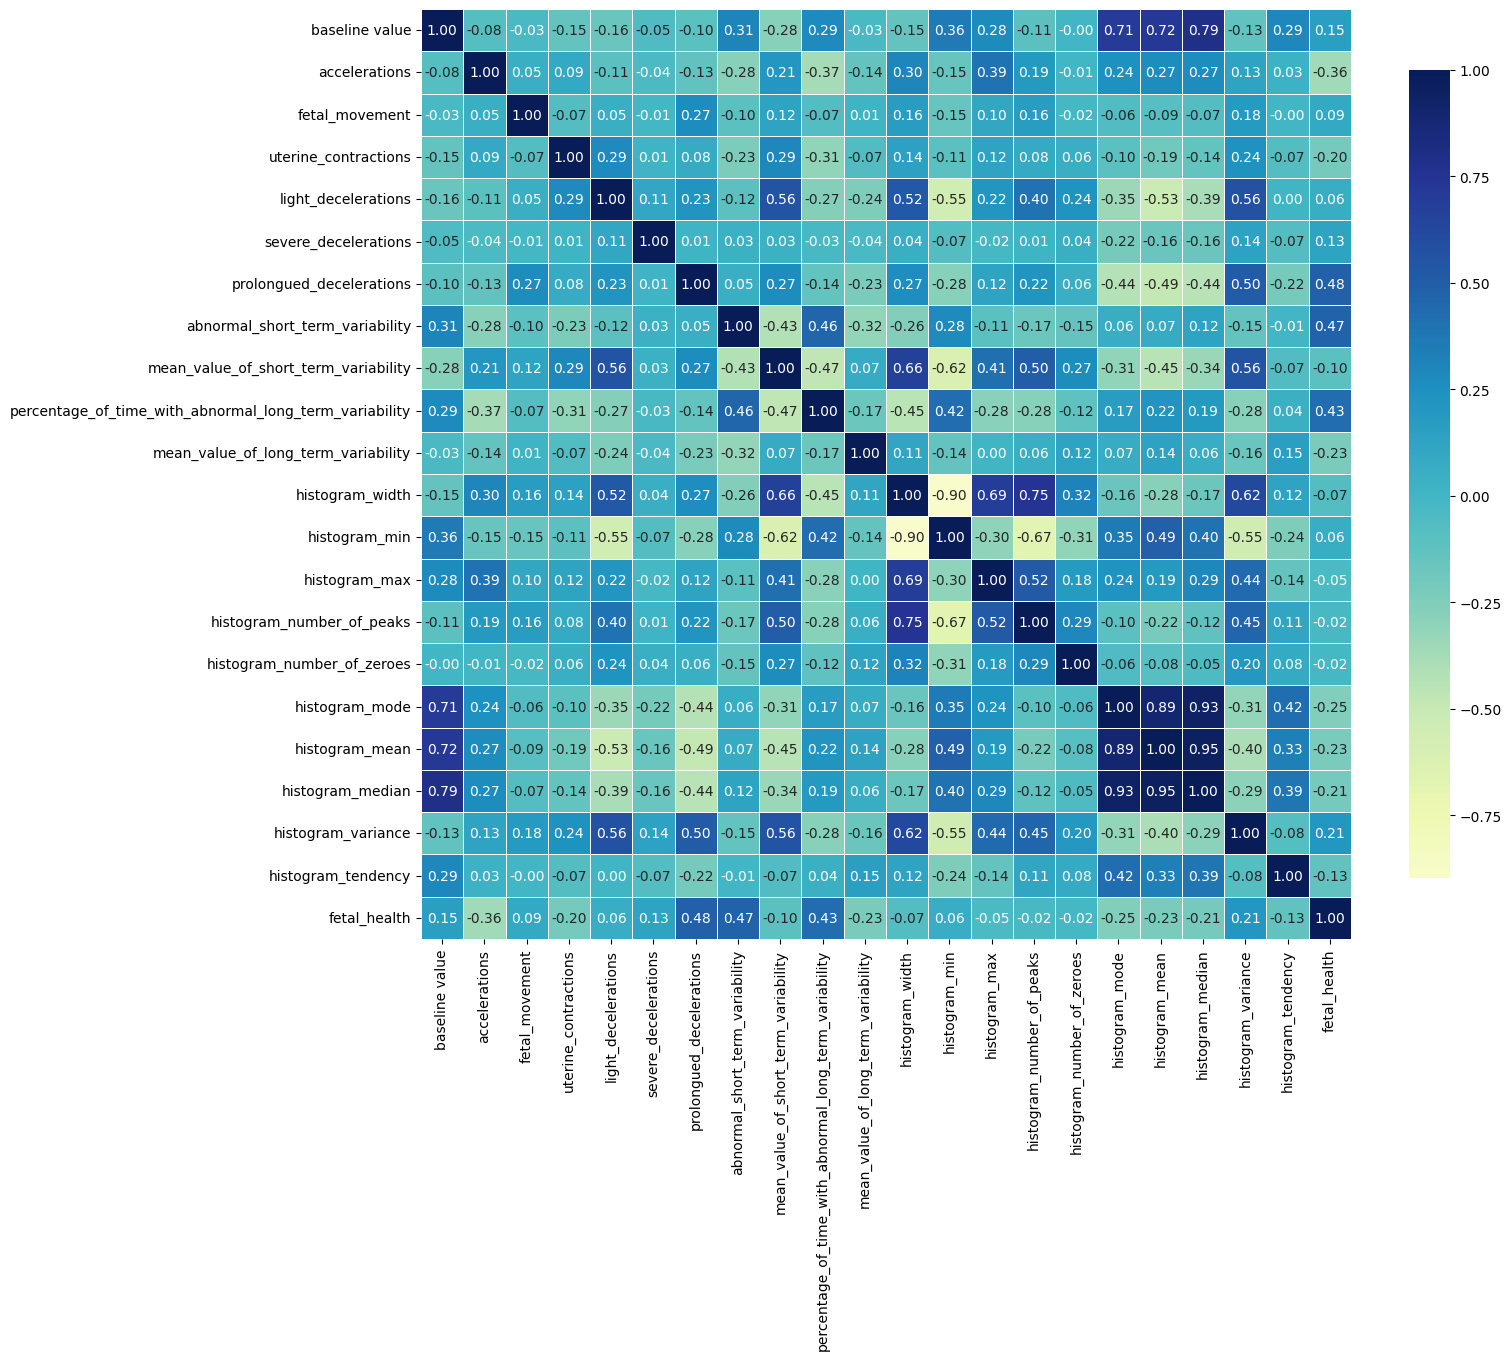

In [16]:
correlation_heatmap(data)

In [17]:
## modelling

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.3, stratify=y)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1488, 18), (1488,), (638, 18), (638,))

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import xgboost
# read data

bst = XGBClassifier(max_depth=6, learning_rate=1, objective="multi:softmax")
# fit model
bst.fit(X_train, y_train)
# make predictions
preds = bst.predict(X_test)
print(classification_report(y_train, bst.predict(X_train)))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1158
         1.0       1.00      0.99      1.00       207
         2.0       1.00      1.00      1.00       123

    accuracy                           1.00      1488
   macro avg       1.00      1.00      1.00      1488
weighted avg       1.00      1.00      1.00      1488



In [19]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97       497
         1.0       0.85      0.77      0.81        88
         2.0       0.94      0.89      0.91        53

    accuracy                           0.94       638
   macro avg       0.92      0.88      0.90       638
weighted avg       0.94      0.94      0.94       638



In [20]:
## f1 score = 2 * precision * recall /(precision + recall)
## f_beta = (1+beta^2)precision * recall /(beta^2 * precision + recall)

## beta > 1 --> more attention or weight to the recall in this KPI
## beta < 1 ---> more attention or weight to the precision in this KPI

In [21]:
from sklearn.metrics import f1_score, fbeta_score
print(f1_score(y_test, preds, average = 'weighted'))
print(fbeta_score(y_test, preds, average = 'weighted', beta = 0.5)) # charge more the precision
print(fbeta_score(y_test, preds, average ='weighted', beta = 2)) # charge more the recall

0.942439935765241
0.9421468152819075
0.9430269486266954


In [22]:
print(fbeta_score(y_test, preds,average =None,  beta = 0.5)) # charge more the precision
print(fbeta_score(y_test, preds, average =None, beta = 2)) # charge more the recall

[0.96283116 0.83333333 0.92885375]
[0.9755609  0.78703704 0.89694656]


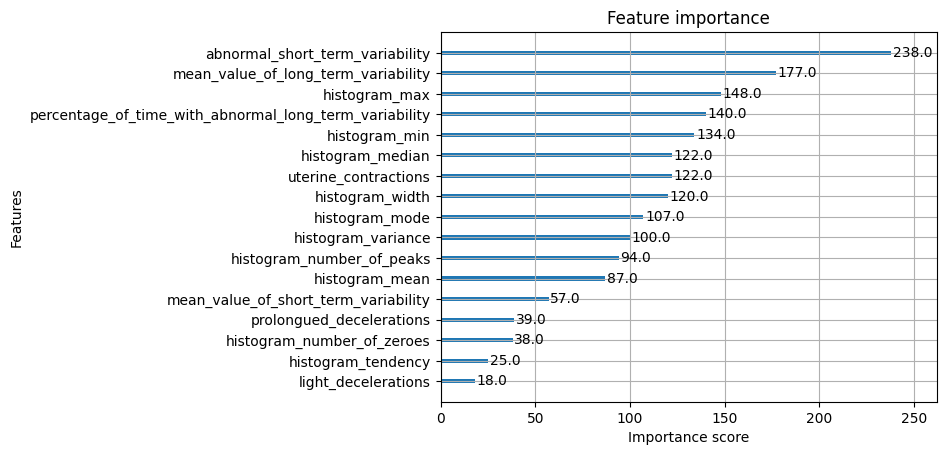

In [23]:

# Plot feature importance
xgboost.plot_importance(bst)
plt.show()

In [24]:
#! pip install shap

In [25]:
## stacking: MODEL ASSESSMENT


rf = RandomForestClassifier(random_state=55, class_weight= "balanced_subsample")
lr = LogisticRegression(random_state=55, multi_class= "multinomial")
sv = SVC(probability=True, random_state=55)
#logreg = LogisticRegression(n_jobs =-1, solver = "nwton-cg", random_state=55)
gb = GradientBoostingClassifier(random_state=55)
gnb = GaussianNB()
xgb = XGBClassifier(random_state =55)



In [26]:
models = [rf, lr, sv, gb, gnb, xgb]

cv = StratifiedKFold(10, shuffle=True, random_state=42)

In [27]:
# run the models

model_results = pd.DataFrame()
row_number = 0
results = []
names = []

for ml in models:
    model_name = ml.__class__.__name__
    cv_results = cross_validate(ml, X_train, y_train, cv = cv, scoring = "f1_macro", return_train_score=True, n_jobs =-1)
    model_results .loc[row_number, "Model Name"] = model_name
    model_results .loc[row_number, "Train accuracy mean"] = cv_results["train_score"].mean()
    model_results .loc[row_number, "Test accuracy mean"] = cv_results["test_score"].mean()
    results.append(cv_results)
    names.append(model_name)
    row_number +=1

In [28]:
model_results

,Model Name,Train accuracy mean,Test accuracy mean
0,RandomForestClassifier,0.998319,0.875773
1,LogisticRegression,0.708858,0.698665
2,SVC,0.695602,0.691727
3,GradientBoostingClassifier,0.989963,0.899573
4,GaussianNB,0.681607,0.670583
5,XGBClassifier,0.998309,0.895153


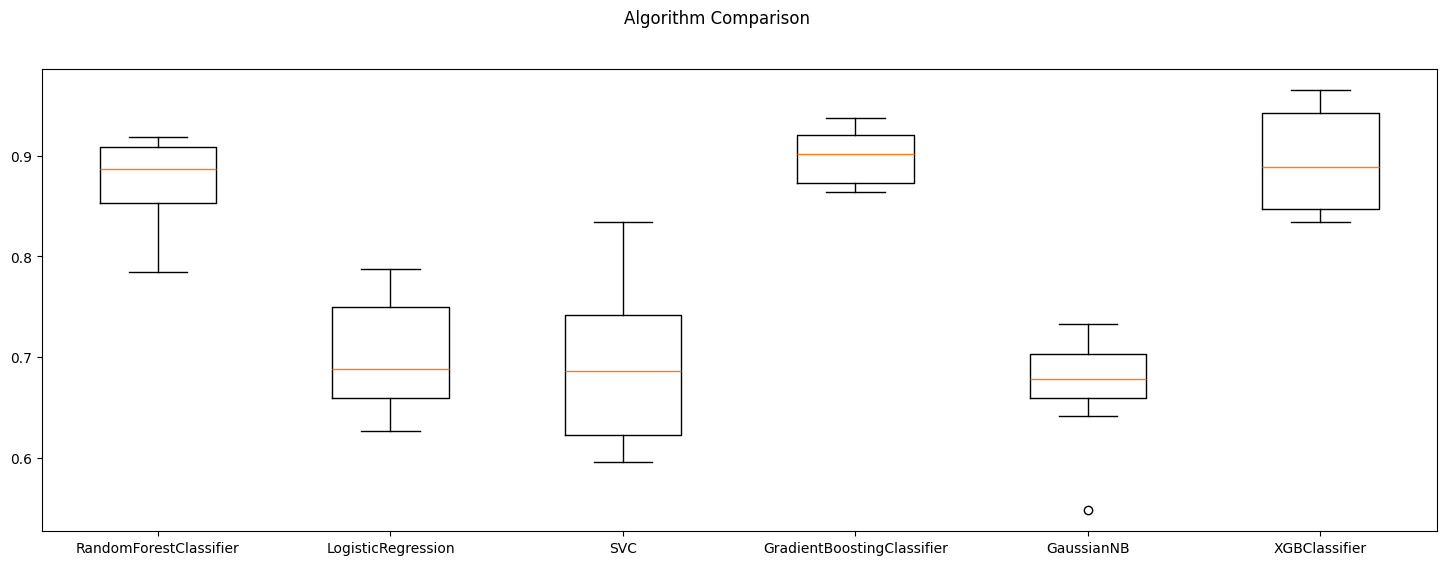

In [29]:
# store results

cv_results_array = []
for tt in results:
    cv_results_array.append(tt["test_score"])

fig = plt.figure(figsize =(18,6))
fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)
plt.boxplot(cv_results_array)
ax.set_xticklabels(names)
plt.show()

In [30]:
## stacking

from sklearn.ensemble import StackingClassifier

estimators = [
    ("rf", RandomForestClassifier(random_state=55, class_weight="balanced_subsample")),
    ("gb", GradientBoostingClassifier(random_state=55)),
    ("xgb", XGBClassifier(random_state =55))
]

clf = StackingClassifier( estimators=estimators, final_estimator= RandomForestClassifier(random_state=55), cv=5)

In [31]:
clf.fit(X_train, y_train).score(X_test, y_test)

0.9420062695924765

In [32]:
clf2 = StackingClassifier( estimators=estimators, final_estimator= xgb, cv=5)

clf2.fit(X_train, y_train).score(X_test, y_test)

0.9420062695924765

In [33]:
xgb = XGBClassifier(random_state =55)
xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [34]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train)

classes = ["Normal", "Suspect", "Pathological"]

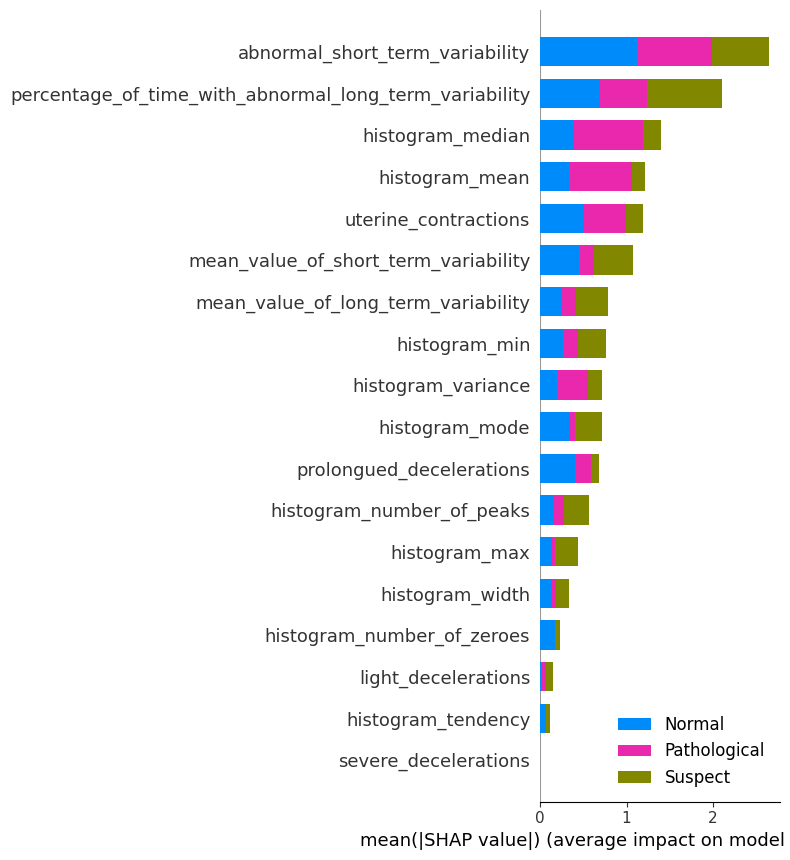

In [35]:
shap.summary_plot(shap_values, X_train, plot_type="bar", class_names =classes)